# Análise Descritiva - Dashboard
##### O objetivo deste notebook é demonstrar as transformações de dados feitas no Power BI, assim como algumas das análises ali presentes, porém em código.

## 0 - Importações

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1 - Concatenação de todos os dados em um único arquivo .csv

In [29]:
viewing = [
    '../dados/GabrielKoji/ViewingActivityKoji.csv',
    '../dados/JoãoVargas/ViewingActivityJoao.csv',
    '../dados/RafaelCruz/ViewingActivityRafa.csv',
    '../dados/RaissaCasale/ViewingActivityRaissa.csv',
    '../dados/RyanLionel/ViewingActivityRyan.csv'
]

df = pd.concat([pd.read_csv(f) for f in viewing], ignore_index=True) 

display(df)

,Duration,Start Time,Profile Name,Country,Bookmark,Latest Bookmark,Supplemental Video Type,Attributes,Device Type,Title
0,00:00:05,2026-01-30 14:59:45,Extra,BR (Brazil),00:56:20,00:56:20,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
1,00:05:47,2026-01-30 14:39:46,Extra,BR (Brazil),00:54:40,Not latest view,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
2,00:40:58,2026-01-30 09:18:13,Extra,BR (Brazil),00:40:09,Not latest view,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 1: Diamante raro (episód...
3,00:00:38,2026-01-30 08:40:42,Extra,BR (Brazil),00:25:59,00:25:59,NaN,NaN,DefaultWidevineAndroidPhone,Bridgerton: Temporada 4: Um Perfeito Cavalheir...
4,00:06:37,2026-01-30 01:26:09,Extra,BR (Brazil),00:20:14,00:20:14,NaN,NaN,Chrome OS (Cadmium),Dr. House: Temporada 5: Simple Explanation (ep...
...,...,...,...,...,...,...,...,...,...,...
107567,00:00:30,2015-12-04 08:56:45,Ryan,BR (Brazil),00:13:20,00:13:20,NaN,NaN,Mobile,Zé Colmeia: O Filme
107568,00:00:55,2015-12-04 08:55:16,Ryan,BR (Brazil),00:29:19,Not latest view,NaN,NaN,Mobile,Os Pinguins de Madagascar – O Filme
107569,00:07:48,2015-12-04 08:45:39,Ryan,BR (Brazil),00:00:23,Not latest view,NaN,NaN,Mobile,Toy Story 2
107570,00:05:08,2015-12-04 08:39:27,Ryan,BR (Brazil),00:00:00,Not latest view,NaN,NaN,Mobile,Toy Story 3


## 2.1 - Eliminação de colunas desnecessárias para a análise

In [30]:
df.drop(["Profile Name", "Attributes", "Supplemental Video Type", "Device Type",
"Bookmark", "Latest Bookmark", "Country"], axis=1, inplace=True)
df.head()

,Duration,Start Time,Title
0,00:00:05,2026-01-30 14:59:45,Bridgerton: Temporada 1: Diamante raro (episód...
1,00:05:47,2026-01-30 14:39:46,Bridgerton: Temporada 1: Diamante raro (episód...
2,00:40:58,2026-01-30 09:18:13,Bridgerton: Temporada 1: Diamante raro (episód...
3,00:00:38,2026-01-30 08:40:42,Bridgerton: Temporada 4: Um Perfeito Cavalheir...
4,00:06:37,2026-01-30 01:26:09,Dr. House: Temporada 5: Simple Explanation (ep...


## 2.2 - Verificação e formatação de colunas

In [31]:
df.columns = ['Duration','Start_Time', 'Title']
df.isna().values.any()
df.dtypes

Duration      object
Start_Time    object
Title         object
dtype: object

In [32]:
#A coluna 'Start_Time' é convertida para o tipo datetime, considerando o formato misto, dia primeiro e fuso horário UTC.
df['Start_Time'] = pd.to_datetime(
    df['Start_Time'],
    format='mixed',
    dayfirst=True,
    utc=True
)

df.dtypes

print("Data mínima:", df['Start_Time'].min())
print("Data máxima:", df['Start_Time'].max())

Data mínima: 2014-04-23 01:06:41+00:00
Data máxima: 2026-02-01 14:19:35+00:00


In [33]:
# transformar Date em índice
df = df.set_index('Start_Time')

# Converter o fuso horário
df.index = df.index.tz_convert('America/Sao_Paulo')

# Voltar Date para coluna
df = df.reset_index()

df.head()


,Start_Time,Duration,Title
0,2026-01-30 11:59:45-03:00,00:00:05,Bridgerton: Temporada 1: Diamante raro (episód...
1,2026-01-30 11:39:46-03:00,00:05:47,Bridgerton: Temporada 1: Diamante raro (episód...
2,2026-01-30 06:18:13-03:00,00:40:58,Bridgerton: Temporada 1: Diamante raro (episód...
3,2026-01-30 05:40:42-03:00,00:00:38,Bridgerton: Temporada 4: Um Perfeito Cavalheir...
4,2026-01-29 22:26:09-03:00,00:06:37,Dr. House: Temporada 5: Simple Explanation (ep...


In [34]:
df['Duration'] = pd.to_timedelta(df['Duration'])
df.dtypes


Start_Time    datetime64[ns, America/Sao_Paulo]
Duration                        timedelta64[ns]
Title                                    object
dtype: object

In [35]:
#criando novas colunar 'Temporada' e 'Episodio' utilizando a coluna 'Title_Name'
df[['Title_Name', 'Temporada', 'Episodio']] = df['Title'].str.split(': ',n=2, expand=True)

df.drop('Title', axis=1, inplace=True)

df.head()   

,Start_Time,Duration,Title_Name,Temporada,Episodio
0,2026-01-30 11:59:45-03:00,0 days 00:00:05,Bridgerton,Temporada 1,Diamante raro (episódio 1)
1,2026-01-30 11:39:46-03:00,0 days 00:05:47,Bridgerton,Temporada 1,Diamante raro (episódio 1)
2,2026-01-30 06:18:13-03:00,0 days 00:40:58,Bridgerton,Temporada 1,Diamante raro (episódio 1)
3,2026-01-30 05:40:42-03:00,0 days 00:00:38,Bridgerton,Temporada 4,Um Perfeito Cavalheiro (episódio 4)
4,2026-01-29 22:26:09-03:00,0 days 00:06:37,Dr. House,Temporada 5,Simple Explanation (episódio 20)


In [36]:
df['Tipo'] = df['Temporada'].apply(
    lambda x: 'Filme' if pd.isna(x) else 'Série'
)

df['Tipo'].value_counts()


Tipo
Série    68816
Filme    38756
Name: count, dtype: int64

In [37]:
# Criando novas colunas de 'Mês' e 'Hora' utilizando a coluna 'Start_Time'
df['Mês'] = df['Start_Time'].dt.weekday

df['Hora'] = df['Start_Time'].dt.hour

df.head()

,Start_Time,Duration,Title_Name,Temporada,Episodio,Tipo,Mês,Hora
0,2026-01-30 11:59:45-03:00,0 days 00:00:05,Bridgerton,Temporada 1,Diamante raro (episódio 1),Série,4,11
1,2026-01-30 11:39:46-03:00,0 days 00:05:47,Bridgerton,Temporada 1,Diamante raro (episódio 1),Série,4,11
2,2026-01-30 06:18:13-03:00,0 days 00:40:58,Bridgerton,Temporada 1,Diamante raro (episódio 1),Série,4,6
3,2026-01-30 05:40:42-03:00,0 days 00:00:38,Bridgerton,Temporada 4,Um Perfeito Cavalheiro (episódio 4),Série,4,5
4,2026-01-29 22:26:09-03:00,0 days 00:06:37,Dr. House,Temporada 5,Simple Explanation (episódio 20),Série,3,22


## 3 - Análises

In [38]:
# Quantidade de plays em cada serie
df['Title_Name'].value_counts()

Title_Name
Unknown Title            1407
Trailer                  1244
Vikings                   811
Temporada 1 (Clipe)       778
Gilmore Girls             595
                         ... 
Encounter                   1
VIPs                        1
Zoo                         1
Mais forte que bombas       1
Sexo sem Compromisso        1
Name: count, Length: 8929, dtype: int64

In [39]:
# Top 10 séries mais assistidas
top_10_series = df.groupby(['Title_Name']).agg({'Duration': 'sum'}).sort_values(by = 'Duration', ascending=False).head(10)
top_10_series.head(10)

,Duration
Title_Name,
Vikings,10 days 23:03:32
Stranger Things,9 days 23:00:15
Alquimia das Almas,7 days 10:23:52
Prison Break,6 days 21:49:26
,6 days 21:34:06
Grimm,6 days 18:21:34
Dr. House,6 days 10:11:14
The Good Wife,6 days 05:07:23
Teen Wolf,6 days 01:32:10


In [40]:
# Top 10 filmes mais assistidos
top_10_filmes = df[df['Temporada'].isna()].groupby(['Title_Name']).agg({'Duration': 'sum'}).sort_values(by = 'Duration', ascending=False).head(10)
top_10_filmes.head(10)


,Duration
Title_Name,
Unknown Title,4 days 17:16:17
Guerreiras do K-Pop,0 days 23:21:29
Alerta Vermelho,0 days 18:05:41
O Protetor,0 days 12:19:01
The Old Guard,0 days 12:18:32
Jason Bourne,0 days 12:08:31
O Mundo Depois de Nós,0 days 10:27:48
A Mãe,0 days 10:04:47
"LG 2016 MStar M2 Low DTV Smart TV,Toy Story 3",0 days 09:53:48


In [41]:
# Quantidade totais de midia assistida
total_duration = df['Duration'].sum()
print(f'Tempo total assistido: {total_duration}')

# Quantidade de midia assistida por mês
df['Month'] = df['Start_Time'].dt.month
media_por_mes = df.groupby('Month')['Title_Name'].nunique()
print(media_por_mes)

# Quantidade totais de midias assistidas
total_titles = df['Title_Name'].nunique()
print(f'Total de títulos assistidos: {total_titles}')

Tempo total assistido: 1296 days 18:37:28
Month
1     1989
2     1005
3     1328
4     1185
5     1125
6     1098
7     1376
8     1375
9     1361
10    1394
11    1539
12    1712
Name: Title_Name, dtype: int64
Total de títulos assistidos: 8929


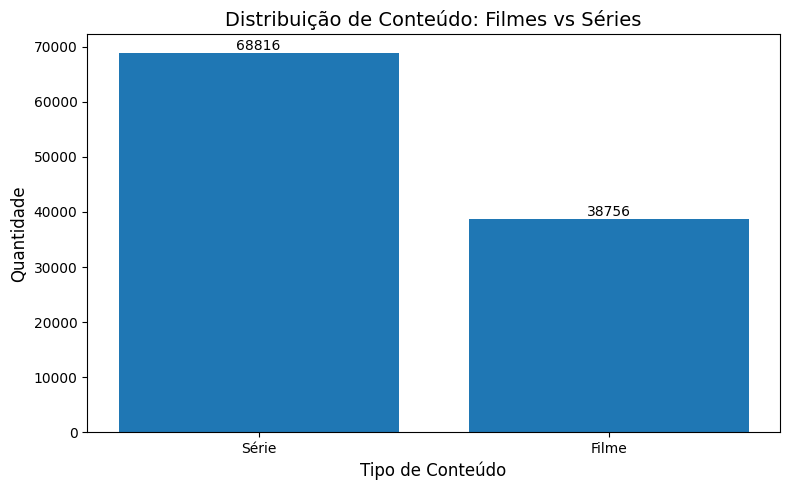

In [42]:
contagem = df['Tipo'].value_counts().sort_values(ascending=False)

# Criação do gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(contagem.index, contagem.values)

plt.title("Distribuição de Conteúdo: Filmes vs Séries", fontsize=14)
plt.xlabel("Tipo de Conteúdo", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)


# Adiciona valores em cima das barras
for i, valor in enumerate(contagem.values):
    plt.text(i, valor, str(valor), ha='center', va='bottom')

plt.tight_layout()
plt.show()


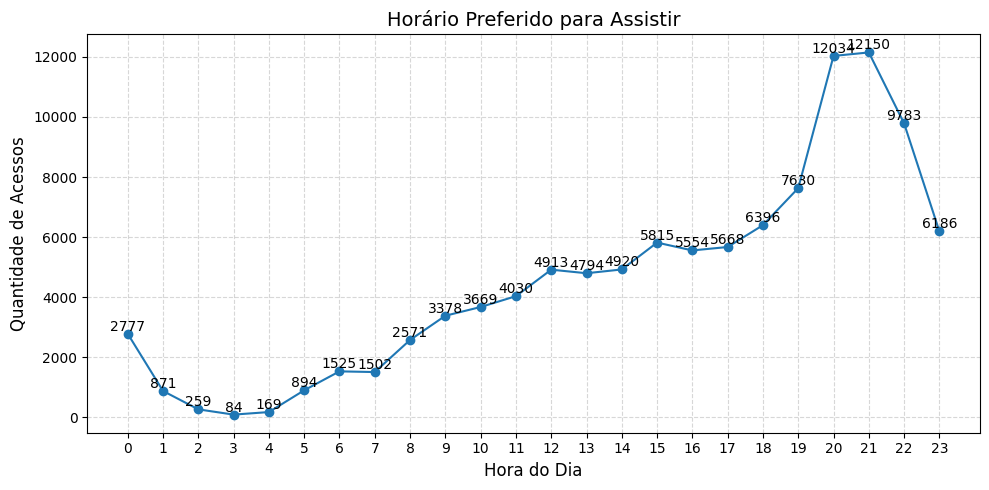

In [43]:
# Agrupa e ordena por hora
acessos_por_hora = df['Hora'].value_counts().sort_index()

plt.figure(figsize=(10,5))

# Cria o gráfico de linha
plt.plot(acessos_por_hora.index, acessos_por_hora.values, marker='o')

# Títulos e rótulos
plt.title("Horário Preferido para Assistir", fontsize=14)
plt.xlabel("Hora do Dia", fontsize=12)
plt.ylabel("Quantidade de Acessos", fontsize=12)

# Melhora visual
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

# Adiciona valores nos pontos
for x, y in zip(acessos_por_hora.index, acessos_por_hora.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

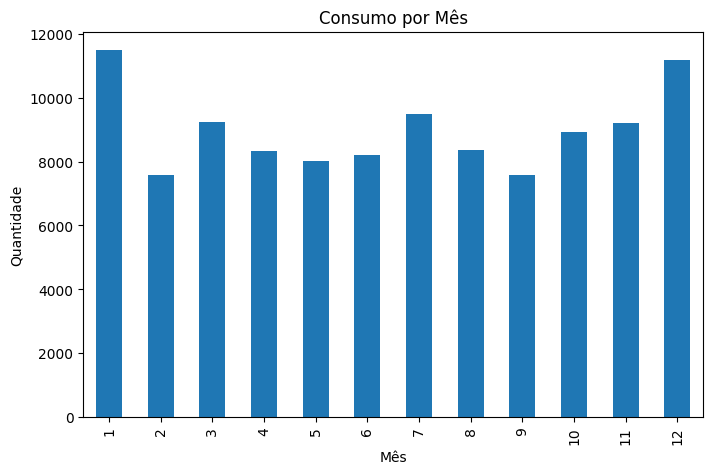

In [44]:
plt.figure(figsize=(8,5))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Consumo por Mês")
plt.xlabel("Mês")
plt.ylabel("Quantidade")
plt.show()

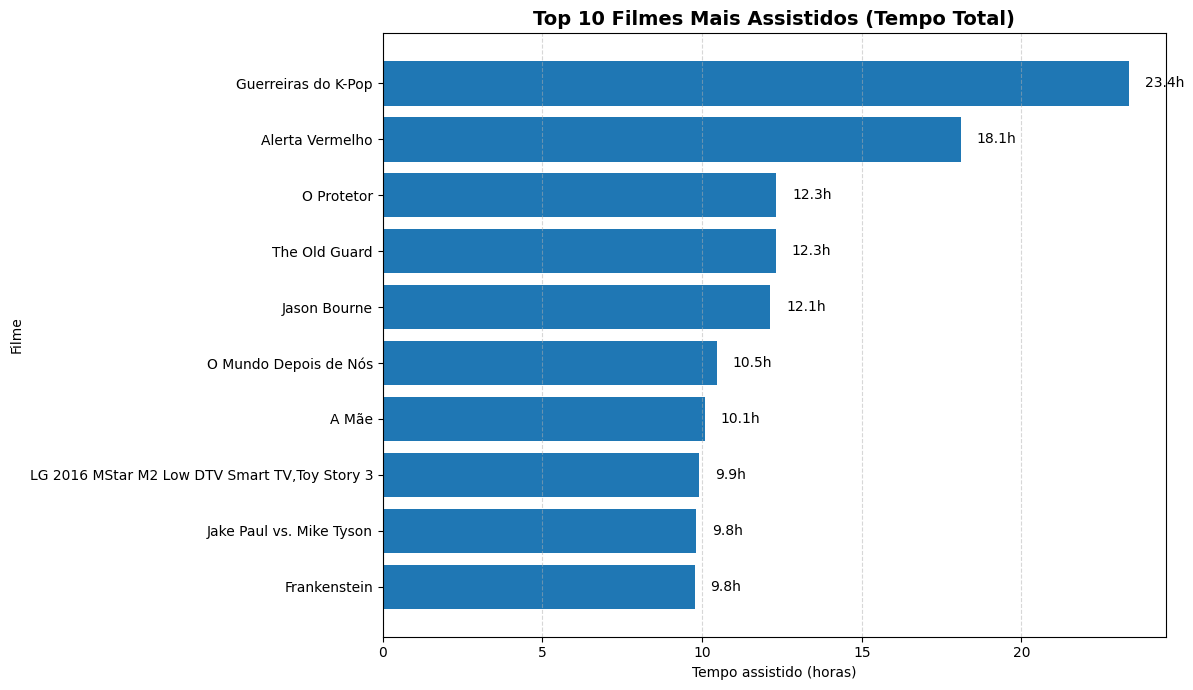

In [ ]:
# Filtrar apenas filmes
filmes = df[df['Tipo'] == 'Filme'].copy()

# Remover títulos nulos ou "Unknown Title"
filmes = filmes[filmes['Title_Name'].notna()]
filmes = filmes[filmes['Title_Name'] != 'Unknown Title']

# Somar tempo total por título
top_filmes = (
    filmes
    .groupby('Title_Name')['Duration']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Converter para horas
top_filmes_horas = top_filmes.dt.total_seconds() / 3600

# Ordenar do menor para o maior para gráfico horizontal ficar bonito
top_filmes_horas = top_filmes_horas.sort_values()

# Plot
plt.figure(figsize=(12, 7))
bars = plt.barh(top_filmes_horas.index, top_filmes_horas.values)

plt.title("Top 10 Filmes Mais Assistidos (Tempo Total)", fontsize=14, weight='bold')
plt.xlabel("Tempo assistido (horas)")
plt.ylabel("Filme")

for i, v in enumerate(top_filmes_horas.values):
    plt.text(v + 0.5, i, f"{v:.1f}h", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

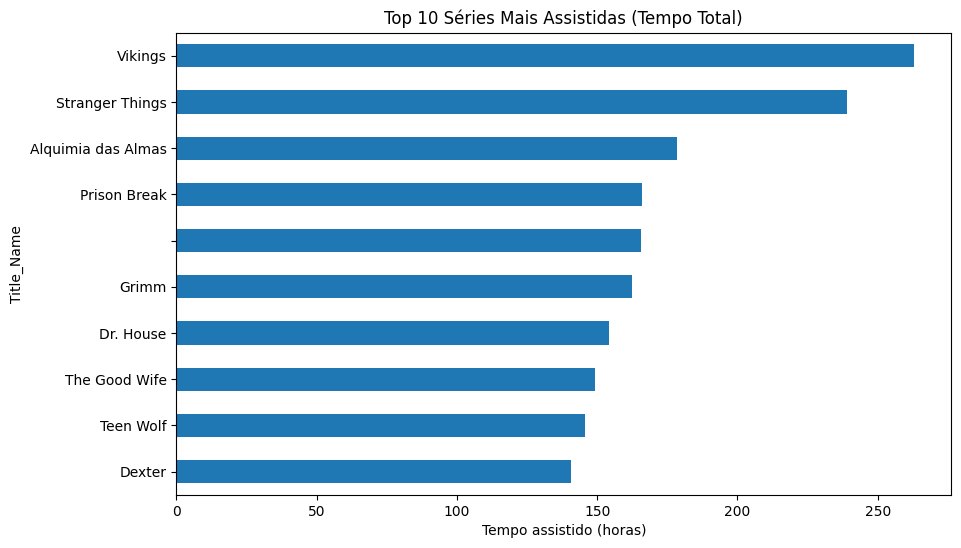

In [ ]:
# Somar tempo total por série
top_series = (
    df[df['Tipo'] == 'Série']
    .groupby('Title_Name')['Duration']
    .sum()
)

top_10_series = top_series.sort_values(ascending=False).head(10)

# Converter para horas
top_10_series_horas = top_10_series.dt.total_seconds() / 3600

plt.figure(figsize=(10,6))
top_10_series_horas.sort_values().plot(kind='barh')
plt.title("Top 10 Séries Mais Assistidas (Tempo Total)")
plt.xlabel("Tempo assistido (horas)")
plt.show()